# Experiment No. 09: Inferential Statistics on Student Marks

## AIM
Conduct inferential statistics tests on a student marks dataset.

## DATASET USED
`Simple 100 Student Marks.csv` (100 students, marks in 5 subjects).

## THEORY OVERVIEW
Inferential statistics uses sample data to estimate population behavior and test claims.

Topics covered:
1. Distributions (Normal and Poisson), population parameters, sampling error
2. Confidence intervals
3. Hypothesis testing: Z-test, t-test, ANOVA

In [10]:
# Imports (kept simple)
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f"{x:0.4f}")

In [11]:
# Load student marks dataset
file_path = 'Simple 100 Student Marks.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (100, 6)
Columns: ['student_name', 'maths_marks', 'science_marks', 'english_marks', 'social_studies_marks', 'language_marks']


,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68


In [12]:
# Select numeric columns (subject marks)
mark_cols = [
    'maths_marks',
    'science_marks',
    'english_marks',
    'social_studies_marks',
    'language_marks'
]

marks_df = df[mark_cols].copy().dropna()

# Main variable for most tests
x = marks_df['maths_marks']

# Count variable for Poisson example: subjects with marks >= 50 for each student
high_score_count = (marks_df >= 50).sum(axis=1)

print('Rows used:', len(marks_df))
marks_df.describe()

Rows used: 100


,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
count,100.0000,100.0000,100.0000,100.0000,100.0000
mean,48.9500,56.0100,52.4800,51.5100,46.1800
std,29.0000,26.4878,27.0254,29.0810,23.5905
min,2.0000,4.0000,1.0000,2.0000,3.0000
25%,27.0000,39.5000,32.0000,29.2500,27.0000
50%,52.5000,59.0000,51.0000,52.5000,42.5000
75%,70.2500,76.0000,76.0000,77.0000,65.0000
max,100.0000,99.0000,97.0000,100.0000,98.0000


## A) Distributions, Population Parameters, and Sampling Error

### Theory
- Normal distribution is often used for continuous values like marks.
- Poisson distribution is used for count data.

### Formulas
Population/sample estimates:
- Mean: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$
- Variance: $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$
- Standard deviation: $s = \sqrt{s^2}$

Sampling error and standard error:
- Sampling error: $\bar{x}_{sample} - \bar{x}_{population\ estimate}$
- Standard error: $SE = \frac{s}{\sqrt{n}}$

In [13]:
# Population parameters and sampling error using maths marks
n = len(x)
mean_x = x.mean()
var_x = x.var(ddof=1)
std_x = x.std(ddof=1)
se_x = std_x / np.sqrt(n)

sample_n = 30
sample_mean = x.sample(sample_n, random_state=42).mean()
sampling_error = sample_mean - mean_x

print('For maths_marks:')
print(f'n = {n}')
print(f'Mean = {mean_x:.4f}')
print(f'Variance = {var_x:.4f}')
print(f'Std Dev = {std_x:.4f}')
print(f'Standard Error = {se_x:.4f}')
print(f'Sampling Error (sample mean - overall mean) = {sampling_error:.4f}')

For maths_marks:
n = 100
Mean = 48.9500
Variance = 840.9975
Std Dev = 29.0000
Standard Error = 2.9000
Sampling Error (sample mean - overall mean) = -1.4167


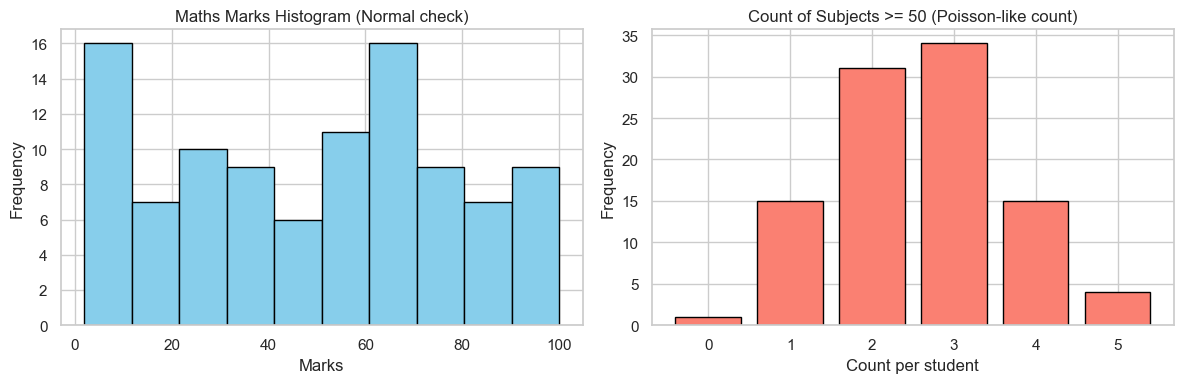

Shapiro-Wilk normality test for maths_marks:
Statistic = 0.9504, p-value = 0.0009

Poisson quick check for high_score_count:
Mean (lambda) = 2.5900
Variance = 1.1534


In [14]:
# Distribution checks: Normal (maths marks) and Poisson (high_score_count)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(x, bins=10, edgecolor='black', color='skyblue')
axes[0].set_title('Maths Marks Histogram (Normal check)')
axes[0].set_xlabel('Marks')
axes[0].set_ylabel('Frequency')

count_vals = high_score_count.value_counts().sort_index()
axes[1].bar(count_vals.index, count_vals.values, color='salmon', edgecolor='black')
axes[1].set_title('Count of Subjects >= 50 (Poisson-like count)')
axes[1].set_xlabel('Count per student')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Normality test
sh_stat, sh_p = stats.shapiro(x)
print('Shapiro-Wilk normality test for maths_marks:')
print(f'Statistic = {sh_stat:.4f}, p-value = {sh_p:.4f}')

# Poisson quick check: mean and variance should be close
lam_hat = high_score_count.mean()
var_count = high_score_count.var(ddof=1)
print('\nPoisson quick check for high_score_count:')
print(f'Mean (lambda) = {lam_hat:.4f}')
print(f'Variance = {var_count:.4f}')

## B) Confidence Interval

### Theory
A confidence interval gives a range of plausible values for a population mean.

### Formula (95% CI for mean)
- Z-based: $\bar{x} \pm z_{0.025}\frac{s}{\sqrt{n}}$
- t-based: $\bar{x} \pm t_{0.025,\,n-1}\frac{s}{\sqrt{n}}$

In [15]:
# 95% Confidence Interval for mean maths marks
alpha = 0.05
xbar = x.mean()
s = x.std(ddof=1)
n = len(x)

z_crit = stats.norm.ppf(1 - alpha / 2)
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)

ci_z = (xbar - z_crit * s / np.sqrt(n), xbar + z_crit * s / np.sqrt(n))
ci_t = (xbar - t_crit * s / np.sqrt(n), xbar + t_crit * s / np.sqrt(n))

print('95% CI for mean maths marks:')
print(f'Z-based CI: ({ci_z[0]:.4f}, {ci_z[1]:.4f})')
print(f't-based CI: ({ci_t[0]:.4f}, {ci_t[1]:.4f})')

95% CI for mean maths marks:
Z-based CI: (43.2661, 54.6339)
t-based CI: (43.1958, 54.7042)


## C) Hypothesis Testing

### 1) Z-test (One sample mean)
#### Theory
Used when population standard deviation is known (or approximated for large samples).

#### Formula
- $H_0: \mu = \mu_0$
- $H_1: \mu \ne \mu_0$
- Test statistic: $z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}$

### 2) t-test (One sample mean)
#### Theory
Used when population standard deviation is unknown.

#### Formula
- $H_0: \mu = \mu_0$
- $H_1: \mu \ne \mu_0$
- Test statistic: $t = \frac{\bar{x}-\mu_0}{s/\sqrt{n}}$

### 3) One-way ANOVA
#### Theory
Compares means of 3 or more groups.

#### Formula
- $H_0: \mu_1 = \mu_2 = \cdots = \mu_k$
- $H_1$: at least one mean is different
- Test statistic: $F = \frac{MSB}{MSW}$

In [16]:
# 1) One-sample Z-test for maths marks (simple manual implementation)
mu0 = 50
sigma_approx = x.std(ddof=1)  # approximation for demonstration

z_stat = (x.mean() - mu0) / (sigma_approx / np.sqrt(len(x)))
z_p = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f'H0: mean maths marks = {mu0}')
print(f'Z statistic = {z_stat:.4f}')
print(f'p-value = {z_p:.4f}')
print('Decision at alpha=0.05:', 'Reject H0' if z_p < 0.05 else 'Fail to reject H0')

H0: mean maths marks = 50
Z statistic = -0.3621
p-value = 0.7173
Decision at alpha=0.05: Fail to reject H0


In [17]:
# 2) One-sample t-test for science marks
mu0 = 50
y = marks_df['science_marks']

t_stat, t_p = stats.ttest_1samp(y, popmean=mu0)

print(f'H0: mean science marks = {mu0}')
print(f't statistic = {t_stat:.4f}')
print(f'p-value = {t_p:.4f}')
print('Decision at alpha=0.05:', 'Reject H0' if t_p < 0.05 else 'Fail to reject H0')

H0: mean science marks = 50
t statistic = 2.2690
p-value = 0.0254
Decision at alpha=0.05: Reject H0


In [18]:
# 3) One-way ANOVA across subject mark columns
f_stat, f_p = stats.f_oneway(
    marks_df['maths_marks'],
    marks_df['science_marks'],
    marks_df['english_marks'],
    marks_df['social_studies_marks'],
    marks_df['language_marks']
)

print('H0: all subject means are equal')
print(f'F statistic = {f_stat:.4f}')
print(f'p-value = {f_p:.4f}')
print('Decision at alpha=0.05:', 'Reject H0' if f_p < 0.05 else 'Fail to reject H0')

H0: all subject means are equal
F statistic = 1.8700
p-value = 0.1144
Decision at alpha=0.05: Fail to reject H0


## Conclusion

Using the student marks dataset, we performed a simple inferential statistics workflow:
- Distribution understanding (Normal and Poisson-style count)
- Population parameter estimation and sampling error
- Confidence interval estimation
- Hypothesis testing using Z-test, t-test, and ANOVA

This notebook is intentionally simple and can be directly used for lab submission.